### Part 2

Identifying an undocumented detection event of WT 2. 
Suspicious Signal: Generator bearing front temperature

In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from helperfunctions.detection import stats as ks
import pandas as pd
from pathlib import Path
import numpy as np
import os
from glob import glob
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
#%matplotlib widget
%matplotlib inline
pd.set_option("display.max_columns", None)
#pd.set_option("display.max_rows", None)

In [2]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)


{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [3]:
print(ic.PATH_PART2_EVAL_TEST)

G:\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\src\Penmanshiel\processed_data\signal_imputation\part2\eval_test_set


In [4]:
test_eval_file = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv")) [0]
test_eval_df = pd.read_csv(test_eval_file, parse_dates=[ic.TS_COL])

display(test_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588306200000000001,2020-05-01 04:10:00,1,0.023558,0.008130,0.094430,0.020689,0.021194,0.007773,0.011155,0.003134,0.006520,0.090018,0.000056,0.000006,0.006935,0.047053,0.238759,0.002414,0.000161,0.001429,0.004876,1.649583e-06,1.111376e-02,0.002910,0.002987,0.003098,0.018373,0.000053,0.000545,0.010954,0.011970,0.012221,0.001962,0.000169,0.004797,0.000044,0.000238,0.012358,0.000070,0.000369,0.236231
1,1588306200000000002,2020-05-01 04:10:00,2,0.029557,0.005792,0.148968,0.018134,0.019813,0.001401,0.010909,0.007578,0.000840,0.008571,0.000693,0.001480,0.000856,0.001693,0.238949,0.006456,0.004947,0.180932,0.000373,2.469104e-02,1.650746e-02,0.002031,0.003662,0.003906,0.011898,0.000295,0.002226,0.011219,0.012063,0.012213,0.014459,0.004076,0.059176,0.013549,0.001775,0.015111,0.004630,0.013773,0.237522
2,1588306200000000004,2020-05-01 04:10:00,4,0.006314,0.000049,0.000005,0.037038,0.032982,0.008757,0.000243,0.000365,0.007453,0.050295,0.000184,0.000002,0.001528,0.003805,0.000094,0.039065,0.002828,0.001940,0.006171,1.590056e-09,1.729905e-07,0.000140,0.000014,0.000174,0.002971,0.000005,0.001642,0.009698,0.010673,0.010733,0.000525,0.000319,0.003303,0.000072,0.000643,0.005931,0.000131,0.000011,0.000132
3,1588306200000000005,2020-05-01 04:10:00,5,0.017932,0.000596,0.034283,0.014542,0.030048,0.014861,0.031468,0.011874,0.013215,0.000290,0.014031,0.004246,0.012108,0.003189,0.000045,0.007801,0.001491,0.003803,0.011490,9.968166e-04,4.981487e-05,0.000004,0.000053,0.000010,0.034265,0.248148,0.010558,0.024552,0.026006,0.025975,0.002284,0.004244,0.015484,0.001149,0.018475,0.049948,0.008763,0.001005,0.000066
4,1588306200000000006,2020-05-01 04:10:00,6,0.013803,0.000001,0.064799,0.000715,0.000020,0.003924,0.000044,0.007019,0.001439,0.000133,0.000966,0.000424,0.004550,0.003468,0.000052,0.004133,0.004309,0.000301,0.000124,2.583641e-03,9.284015e-03,0.039873,0.042636,0.043257,0.002332,0.247331,0.001270,0.008130,0.011353,0.006610,0.000221,0.000380,0.001297,0.001896,0.000083,0.003046,0.002707,0.003556,0.000230


In [5]:
test_eval_clean = p2.drop_imputations(test_eval_df)

In [6]:
theta = p2.load_threshold_table()

   WT_ID    k       mu     sigma  threshold   tp   fn     fp  precision  \
0      1  1.0  0.01538  0.032928   0.048308  7.0  1.0  266.0   0.025641   

   recall        f1  FAR_per_day  latency_mean  
0   0.875  0.049822     1.797297    109.142857  


In [7]:
dets = test_eval_clean[test_eval_clean[ic.MEAN_LOSS_PER_SAMPLE] >= theta]
print(f"Total number of unfiltered Detections: {len(dets)}")

Total number of unfiltered Detections: 176548


### Power Curve 

In [8]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [9]:
test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wt_farm_df = pd.read_csv(ic.PATH_PART2_WT_FARM /  "wt_farm_pc_df.csv")
wt_farm_df[ic.TS_COL] = pd.to_datetime(wt_farm_df[ic.TS_COL])
wt_farm_df.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,1,2020-05-01 04:10:00,5.180120,154.845861
1,1,2020-05-01 04:20:00,4.917112,125.039087
2,1,2020-05-01 04:30:00,5.379890,151.489965
3,1,2020-05-01 04:40:00,4.659290,100.066924
4,1,2020-05-01 04:50:00,5.240885,117.778430


### new


In [10]:
catalog_df = pd.read_csv(ic.PATH_PART2_DETECTIONS / "catalog.csv")

In [11]:
#filtered_cat = catalog_df[catalog_df["flag_sig_shift_event_mean"] == True]

filtered_cat = catalog_df[catalog_df["z_shift"] > 0]
filtered_cat = filtered_cat.sort_values(by=["z_shift"], ascending=False)

In [12]:
display(filtered_cat.head())
display("filtered = ", len(filtered_cat))
display("total detections in catalog", len(catalog_df))

,WT_ID,re_at_ts,Date and time,signal_name,window_start,window_end,wind_center,n_baseline,mean_baseline,std_baseline,mean_event,std_event,value_at_ts,delta_at_ts,z_at_ts,delta_mean,z_shift
511,11,1.277988,2022-07-06 17:40:00,Rotor bearing temp (°C),2022-07-01 09:10:00,2022-07-11 23:40:00,18.5,334,30.719491,2.218025,38.000000,NaN,38.000000,7.280509,3.282429,7.280509,3.282429
720,15,1.877987,2021-08-05 20:30:00,Rotor bearing temp (°C),2021-07-31 19:20:00,2021-08-10 21:20:00,10.5,1531,28.206051,2.335001,35.334077,0.635956,35.344827,7.138776,3.057290,7.128026,3.052686
61,2,0.762518,2021-01-21 12:50:00,Generator bearing front temperature (°C),2021-01-11 08:30:00,2021-01-26 15:10:00,18.5,364,40.650028,6.031678,57.817858,13.421111,66.281669,25.631641,4.249504,17.167830,2.846278
99,4,0.012894,2022-06-28 17:20:00,Rotor bearing temp (°C),2022-06-23 03:10:00,2022-07-03 20:50:00,10.5,1697,30.674582,2.232830,36.553222,0.822422,37.600000,6.925418,3.101632,5.878640,2.632820
517,11,1.059636,2022-07-06 17:40:00,Hub temperature (°C),2022-07-01 09:10:00,2022-07-11 23:40:00,18.5,334,16.817570,2.832417,24.000000,NaN,24.000000,7.182430,2.535795,7.182430,2.535795


'filtered = '

176

'total detections in catalog'

810

### column name adjustements and top event selection

In [13]:
## Dirty Fix
f_c_drop = filtered_cat.drop(columns=["window_start", "window_end"])
f_c_drop = f_c_drop[:1]

cols = ["re_at_ts","mean_baseline","std_baseline","mean_event","std_event","value_at_ts","delta_at_ts","z_at_ts","delta_mean",	"z_shift"]
f_c_drop[cols] = np.floor(f_c_drop[cols]*1000)/1000
f_c_drop = f_c_drop.rename(columns={"re_at_ts": "Signal-wise RE"})
f_c_drop_cp = f_c_drop.copy()

f_c_drop = f_c_drop.rename(columns={"signal_name": "Signal", 
                                    "wind_center": "Wind Center", 
                                    "n_baseline": "Samples NBM", 
                                    "mean_baseline":"μ NBM",
                                    "std_baseline": "σ NBM",
                                    "mean_event": "μ Event",
                                    "std_event": "σ Event",
                                    "value_at_ts": "Value at ts",
                                    "delta_at_ts": "Δ at ts",
                                    "z_at_ts": "z at ts",
                                    "delta_mean": "Δ μ",
                                    "z_shift": "z event"
                                    })
display(f_c_drop)

cols1 = ["WT_ID", "Date and time", "Signal","Wind Center", "Samples NBM","μ NBM","σ NBM"]
cols2 = ["WT_ID","Signal-wise RE", "Date and time", "Signal","Wind Center", "μ Event","σ Event","Value at ts","z at ts","z event"]
fc1 = f_c_drop[cols1].copy()
fc2 = f_c_drop[cols2].copy()
display(fc1)
display(fc2)
ltx = fc1.to_latex(index=False, escape=True, float_format="%.3f")
with open(ic.PATH_PRINTS/"p2_3_nbm.tex", "w", encoding="utf-8") as f:
    f.write(ltx)
    
ltx2 = fc2.to_latex(index=False, escape=True, float_format="%.3f")
with open(ic.PATH_PRINTS/"p2_3_nbm2.tex", "w", encoding="utf-8") as f:
    f.write(ltx2)


,WT_ID,Signal-wise RE,Date and time,Signal,Wind Center,Samples NBM,μ NBM,σ NBM,μ Event,σ Event,Value at ts,Δ at ts,z at ts,Δ μ,z event
511,11,1.277,2022-07-06 17:40:00,Rotor bearing temp (°C),18.5,334,30.719,2.218,38.0,NaN,38.0,7.28,3.282,7.28,3.282


,WT_ID,Date and time,Signal,Wind Center,Samples NBM,μ NBM,σ NBM
511,11,2022-07-06 17:40:00,Rotor bearing temp (°C),18.5,334,30.719,2.218


,WT_ID,Signal-wise RE,Date and time,Signal,Wind Center,μ Event,σ Event,Value at ts,z at ts,z event
511,11,1.277,2022-07-06 17:40:00,Rotor bearing temp (°C),18.5,38.0,NaN,38.0,3.282,3.282


In [14]:
row = 0

In [15]:
detection_ts = filtered_cat[ic.TS_COL].iloc[row]
detection_ts = pd.to_datetime(detection_ts)
anom_span = [(pd.to_datetime(filtered_cat["window_start"].iloc[row]), pd.to_datetime(filtered_cat["window_end"].iloc[row]))]
wt = filtered_cat[ic.WT_ID].iloc[row]


In [16]:
print(detection_ts)
print(wt)

2022-07-06 17:40:00
11


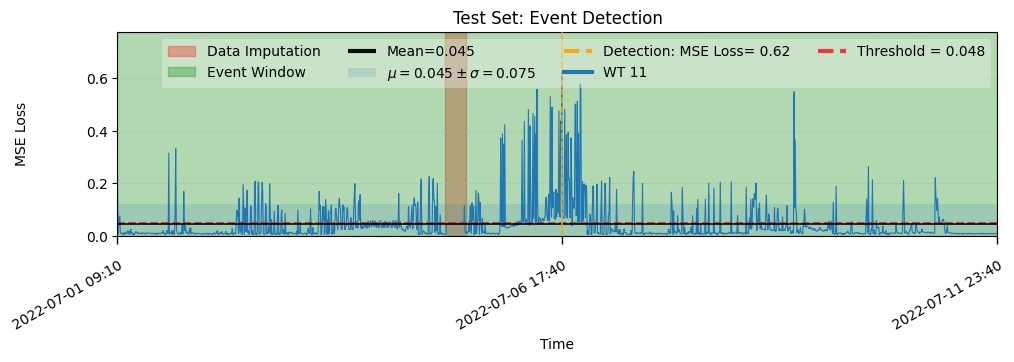

In [17]:
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][ic.MEAN_LOSS_PER_SAMPLE]
loss = f"{loss.iloc[0]: .2f}"

pp.print_loss(test_eval_df,
              dpi=300,
              #y_limits=((0,0.4),(0.4,100)),
              title=f"Test Set: Event Detection",
              wt_id= [wt],
              ts_range=anom_span[0],
              anomaly_spans=anom_span,
              mark_threshold=theta,
              anom_span_label="Event Window",
              detection_ts=[detection_ts],
              impute_label="Data Imputation",
              figsize=(11,3),
              save_filename="p2_3_mean_loss.png",
              detection_label=f"Detection: MSE Loss={loss}",
              y_label = "MSE Loss"
              )

In [18]:
top_signals_wt = p2.get_top_sigs_for_detections(
    eval_df=p2.drop_imputations(test_eval_df),
    selected_detections=filtered_cat,
    wt_id=wt,
    top_n_signals=3
)

print(top_signals_wt)

[(Timestamp('2020-10-17 05:50:00'), ['RE_Tower Acceleration Y (mm/ss)', 'RE_Rear bearing temperature (°C)', 'RE_Rotor bearing temp (°C)']), (Timestamp('2022-06-22 07:50:00'), ['RE_Rotor bearing temp (°C)', 'RE_Hub temperature (°C)', 'RE_Tower Acceleration Y (mm/ss)']), (Timestamp('2022-07-06 17:40:00'), ['RE_Tower Acceleration Y (mm/ss)', 'RE_Rotor bearing temp (°C)', 'RE_Rear bearing temperature (°C)']), (Timestamp('2022-07-25 15:20:00'), ['RE_Tower Acceleration Y (mm/ss)', 'RE_Rear bearing temperature (°C)', 'RE_Vane position 1+2 (°)'])]


In [19]:
filtered_cat[ic.TS_COL] = pd.to_datetime(filtered_cat[ic.TS_COL])

In [20]:
wt_windows = filtered_cat[(filtered_cat[ic.WT_ID] == wt)  & (filtered_cat[ic.TS_COL] == detection_ts)].iloc[[0]]

anomaly_spans_wt = [(pd.to_datetime(row["window_start"]), pd.to_datetime(row["window_end"])) for _,row in wt_windows.iterrows()]
anomaly_spans_wt = sorted(anomaly_spans_wt, key=lambda span: span[0])
print(anomaly_spans_wt)
min_ts = anomaly_spans_wt[0][0]
max_ts = anomaly_spans_wt[-1][1]

[(Timestamp('2022-07-01 09:10:00'), Timestamp('2022-07-11 23:40:00'))]


[(Timestamp('2022-07-01 09:10:00'), Timestamp('2022-07-11 23:40:00'))]


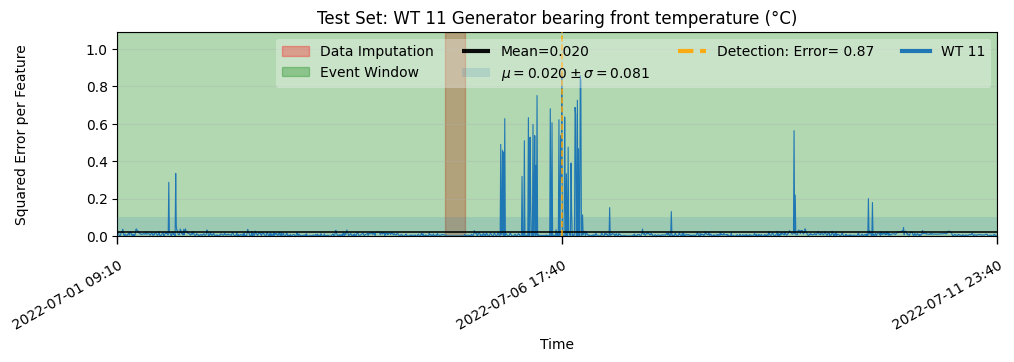

In [21]:
sig = "Generator bearing front temperature (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
print(anom_span)
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )


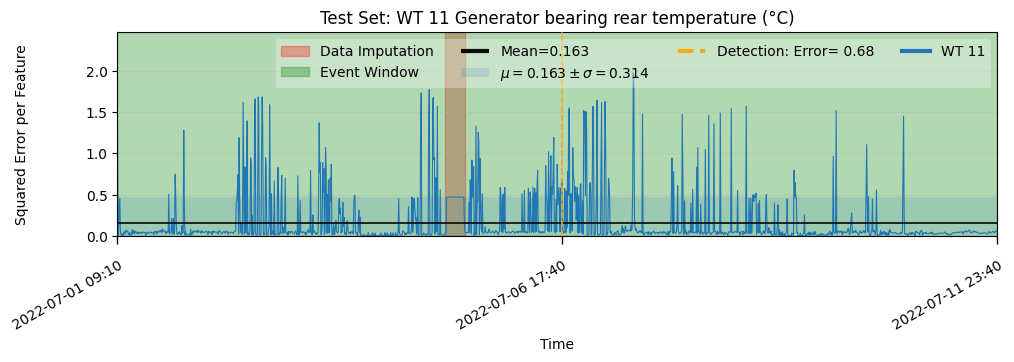

In [22]:
sig = "Generator bearing rear temperature (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )

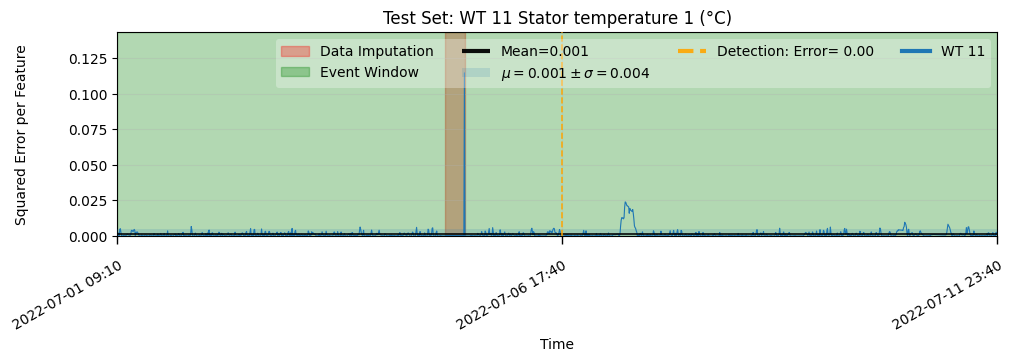

In [23]:
sig = "Stator temperature 1 (°C)"
loss = test_eval_df[(test_eval_df[ic.WT_ID] == wt) & (test_eval_df[ic.TS_COL] == detection_ts)][f"RE_{sig}"]
loss = f"{loss.iloc[0]: .2f}"
pp.print_loss(test_eval_df,
                    dpi=300,
                    title=f"Test Set: WT {wt} {sig}",
                    wt_id= [wt],
                    values=f"RE_{sig}",
                    ts_range=(min_ts, max_ts),
                    anomaly_spans=anom_span,
                    mark_threshold=None,
                    anom_span_label="Event Window",
                    detection_ts=[detection_ts],
                    detection_label=f"Detection: Error={loss}",
                    impute_label="Data Imputation",
                    figsize=(11,3),
                    save_filename=f"p2_3_signal_loss_{sig}",
                    y_label= "Squared Error per Feature",
                    )

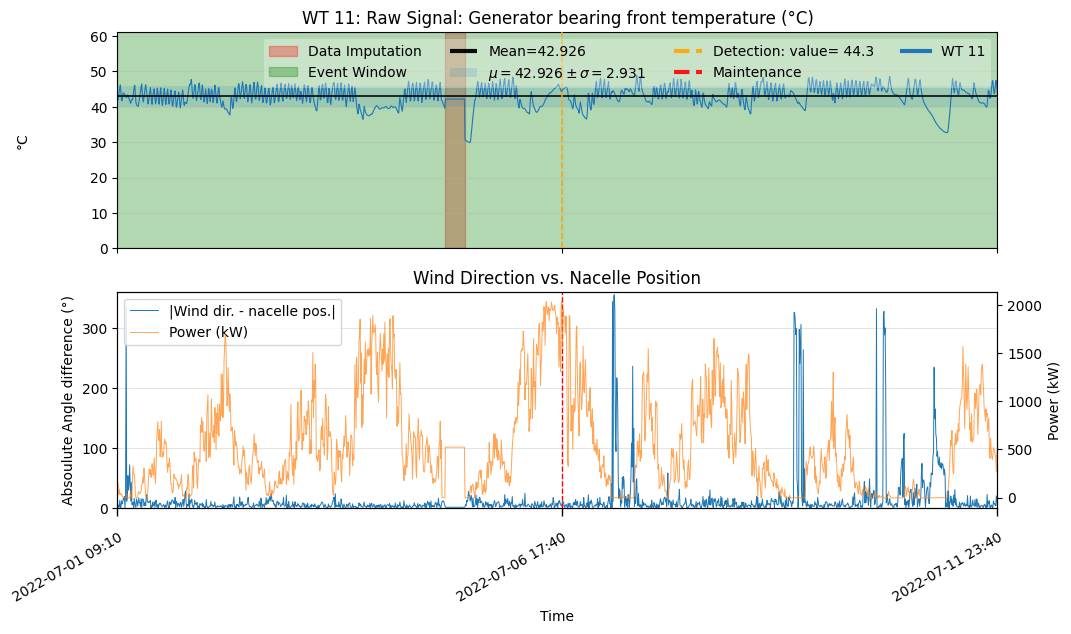

In [24]:
sig = "Generator bearing front temperature (°C)"
#date before large shift occured in generator bearing front temp.
maintenance = pd.to_datetime("2021-01-18 18:00:00") # see logs

fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
wt_df = pd.read_csv(next(iter(fp)), parse_dates=[ic.TS_COL])
wt_df = wt_df[(wt_df[ic.TS_COL] >= cfg_part2.test_start_time) & (wt_df[ic.TS_COL] <= cfg_part2.test_end_time)]
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]

val = f"{val.iloc[0]: .1f}"

pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal: {sig}",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                marker=maintenance, 
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,7),
                #save_filename=None,
                save_filename=f"p2_3_raw_signals_{sig}_plus_wind_nacelle",
                add_wind_vs_nacelle=True,
                )

In [25]:
power = wt_df[wt_df[ic.TS_COL] == (maintenance + pd.Timedelta(hours=2))]
display(power)


,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
236798,11,12.176336,2021-01-18 20:00:00,5.921475,161.073791,471.84721,1333.257663,42.17216,40.145416,1334.002515,17.961747,0.405951,0.870615,0.737866,9.40763,204.596691,18.539954,524.118265,30.833295,12.649621,62.745057,25.096321,43.039357,43.510132,41.737699,0.274093,203.339749,6.479408,1.15994,1.140186,1.150644,61.137373,50.102339,54.926094,58.983794,50.514222,19.601595,14.665392,46.879911,204.598736


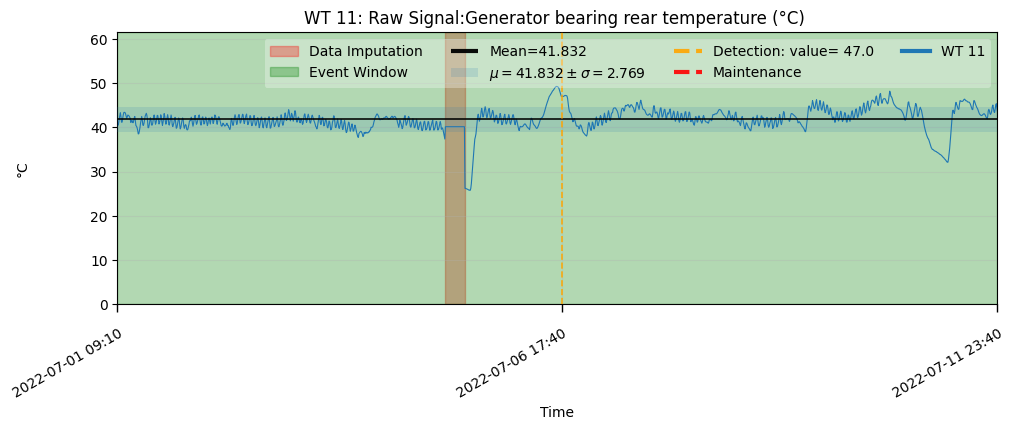

In [26]:
sig = "Generator bearing rear temperature (°C)"
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]
val = f"{val.iloc[0]: .1f}"
pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal:{sig} ",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,4),
                save_filename=f"p2_3_raw_signals_{sig}.png",
                marker=maintenance,
                )

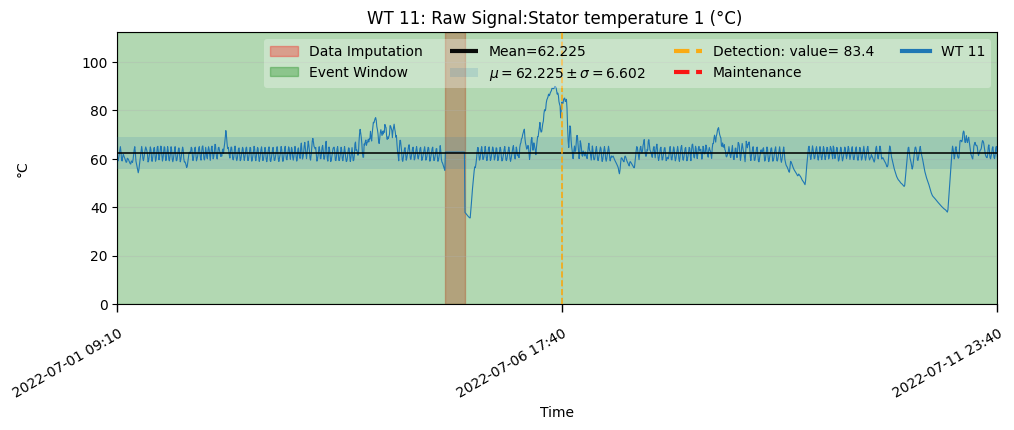

In [27]:
sig = "Stator temperature 1 (°C)"
val = wt_df[(wt_df[ic.WT_ID] == wt) & (wt_df[ic.TS_COL] == detection_ts)][sig]
val = f"{val.iloc[0]: .1f}"
pp.print_loss(wt_df, 
                values=sig,
                title=f"WT {wt}: Raw Signal:{sig} ",
                wt_id=[wt],
                ts_range= (min_ts, max_ts),
                anomaly_spans=anomaly_spans_wt,
                detection_label=f"Detection: value={val}",
                detection_ts= [detection_ts],
                y_label = pp.unit(sig),
                anom_span_label="Event Window",
                impute_label="Data Imputation",
                figsize=(11,4),
                save_filename=f"p2_3_raw_signals_{sig}.png",
                marker=maintenance,
                add_wind_vs_nacelle=False
                )

# Descriptive Analysis

In [28]:
thermal_signals = [sig for sig in hfn.load_feature_order() if "(°C)" in sig]
for sig in thermal_signals:
    print(sig)

Ambient temperature (converter) (°C)
Generator bearing front temperature (°C)
Generator bearing rear temperature (°C)
Hub temperature (°C)
Nacelle ambient temperature (°C)
Nacelle temperature (°C)
Rotor bearing temp (°C)
Stator temperature 1 (°C)
Temp. top box (°C)
Temperature motor axis 1 (°C)
Temperature motor axis 2 (°C)
Temperature motor axis 3 (°C)
Front bearing temperature (°C)
Gear oil inlet temperature (°C)
Gear oil temperature (°C)
Rear bearing temperature (°C)
Transformer cell temperature (°C)
Transformer temperature (°C)


In [29]:
display(hfn.load_feature_order())

['Ambient temperature (converter) (°C)',
 'Drive train acceleration (mm/ss)',
 'Gear oil inlet pressure (bar)',
 'Gear oil pump pressure (bar)',
 'Gearbox speed (RPM)',
 'Generator bearing front temperature (°C)',
 'Generator bearing rear temperature (°C)',
 'Generator RPM (RPM)',
 'Hub temperature (°C)',
 'Motor current axis 1 (A)',
 'Motor current axis 2 (A)',
 'Motor current axis 3 (A)',
 'Nacelle ambient temperature (°C)',
 'Nacelle position (°)',
 'Nacelle temperature (°C)',
 'Power (kW)',
 'Rotor bearing temp (°C)',
 'Rotor speed (RPM)',
 'Stator temperature 1 (°C)',
 'Temp. top box (°C)',
 'Temperature motor axis 1 (°C)',
 'Temperature motor axis 2 (°C)',
 'Temperature motor axis 3 (°C)',
 'Vane position 1+2 (°)',
 'Wind direction (°)',
 'Wind speed (m/s)',
 'Blade angle (pitch position) A (°)',
 'Blade angle (pitch position) B (°)',
 'Blade angle (pitch position) C (°)',
 'Front bearing temperature (°C)',
 'Gear oil inlet temperature (°C)',
 'Gear oil temperature (°C)',
 'Rear 

In [30]:
cpus = os.cpu_count() - 1
#alpha = 0.05
def proc_col(col:str, wt_df, det_ts: pd.Timestamp, offset: pd.Timedelta):
    try:
        pr = ks.get_statistics(
        df=wt_df,
        col=col,
        ts_det=det_ts,
        offset=offset,
        )
        return {"ok": True, "col": col, "res": pr, "err": None}
    except Exception as e:
        return {"ok": False, "col": col, "res": None, "err": e}
    
jobs = Parallel(n_jobs=cpus, backend="loky")(delayed(proc_col)(col,wt_df,detection_ts, pd.Timedelta(days=7)) for col in tqdm(thermal_signals))

for j in jobs:
    if j["ok"] == False:
        raise ValueError(f"Error occured")

pipeline_results = [j["res"] for j in jobs]
    

  0%|          | 0/18 [00:00<?, ?it/s]

In [31]:
df_total = ks.report_total_many(pipeline_results)


g:\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\src\helperfunctions\detection.py:1518: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  }]).round(3)


In [32]:
df_total = df_total[df_total["cliff's delta (raw)"] > 0]
df_total = df_total.sort_values(by=["cliff's delta (raw)"], ascending=[False])
display(df_total)
df_total = df_total.loc[[1,7,2]]
display(df_total)
relevant_sigs = df_total["signal"].tolist()
print(relevant_sigs)

,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
3,11,2022-07-06 17:40:00,Hub temperature (°C),3.715,0.470,0.910
16,11,2022-07-06 17:40:00,Transformer cell temperature (°C),4.474,0.212,0.728
0,11,2022-07-06 17:40:00,Ambient temperature (converter) (°C),4.455,0.383,0.673
4,11,2022-07-06 17:40:00,Nacelle ambient temperature (°C),3.899,0.538,0.670
6,11,2022-07-06 17:40:00,Rotor bearing temp (°C),2.406,-0.346,0.582
17,11,2022-07-06 17:40:00,Transformer temperature (°C),6.642,-0.342,0.500
5,11,2022-07-06 17:40:00,Nacelle temperature (°C),2.802,0.433,0.483
2,11,2022-07-06 17:40:00,Generator bearing rear temperature (°C),1.705,-0.516,0.480
8,11,2022-07-06 17:40:00,Temp. top box (°C),0.817,0.523,0.380
1,11,2022-07-06 17:40:00,Generator bearing front temperature (°C),1.268,-0.405,0.227


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
1,11,2022-07-06 17:40:00,Generator bearing front temperature (°C),1.268,-0.405,0.227
7,11,2022-07-06 17:40:00,Stator temperature 1 (°C),0.223,-0.520,0.046
2,11,2022-07-06 17:40:00,Generator bearing rear temperature (°C),1.705,-0.516,0.480


['Generator bearing front temperature (°C)', 'Stator temperature 1 (°C)', 'Generator bearing rear temperature (°C)']


In [33]:
os.makedirs(ic.PATH_PART2_stats, exist_ok=True)
df_total.to_csv(ic.PATH_PART2_stats / "wt2_stats.csv", index=False)

ltx6 = df_total.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks.tex", "w", encoding="utf-8") as f:
    f.write(ltx6)
    

In [34]:
jobs = Parallel(n_jobs=cpus, backend="loky")(delayed(proc_col)(col,wt_df,detection_ts, pd.Timedelta(days=60)) for col in tqdm(thermal_signals))

for j in jobs:
    if j["ok"] == False:
        raise ValueError(f"Error occured")

pipeline_results2 = [j["res"] for j in jobs]
df_total2 = ks.report_total_many(pipeline_results2)


  0%|          | 0/18 [00:00<?, ?it/s]

g:\bsc-arbeit\git\Explorative-AD-in-Wind-Turbine-SCADA-Data-Using-an-AE\src\helperfunctions\detection.py:1518: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  }]).round(3)


In [35]:
df_total2 = df_total2[df_total2["cliff's delta (raw)"] > 0]
df_total2 = df_total2.sort_values(by=["cliff's delta (raw)"], ascending=[False])
display(df_total2)


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
3,11,2022-07-06 17:40:00,Hub temperature (°C),2.941,0.291,0.647
4,11,2022-07-06 17:40:00,Nacelle ambient temperature (°C),3.126,0.198,0.566
0,11,2022-07-06 17:40:00,Ambient temperature (converter) (°C),2.799,0.161,0.472
16,11,2022-07-06 17:40:00,Transformer cell temperature (°C),2.516,0.074,0.455
5,11,2022-07-06 17:40:00,Nacelle temperature (°C),2.909,0.087,0.446
8,11,2022-07-06 17:40:00,Temp. top box (°C),1.045,0.207,0.343
2,11,2022-07-06 17:40:00,Generator bearing rear temperature (°C),1.180,0.448,0.211
1,11,2022-07-06 17:40:00,Generator bearing front temperature (°C),1.170,0.371,0.182
6,11,2022-07-06 17:40:00,Rotor bearing temp (°C),0.286,0.325,0.126
13,11,2022-07-06 17:40:00,Gear oil inlet temperature (°C),0.236,0.164,0.017


In [36]:
keep_idx = [1,2]
df_total2 = df_total2.loc[keep_idx]
display(df_total2)


,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
1,11,2022-07-06 17:40:00,Generator bearing front temperature (°C),1.17,0.371,0.182
2,11,2022-07-06 17:40:00,Generator bearing rear temperature (°C),1.18,0.448,0.211


In [37]:
df_total2.to_csv(ic.PATH_PART2_stats / "wt2_stats_wide_range.csv", index=False)
ltx7 = df_total2.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks_wide.tex", "w", encoding="utf-8") as f:
    f.write(ltx7)

In [38]:
ltx6 = df_total.to_latex(index=False, escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_ks.tex", "w", encoding="utf-8") as f:
    f.write(ltx6)
    

In [39]:
wind_col = "Wind speed (m/s)"
power_col = "Power (kW)"
df_det_keys = filtered_cat[[ic.WT_ID, ic.TS_COL]].copy()
df_det_keys2 = df_det_keys.drop_duplicates([ic.WT_ID, ic.TS_COL])
df_det_points = df_det_keys2.merge(
    wt_farm_df[[ic.WT_ID,ic.TS_COL, wind_col, power_col]],
    on=[ic.WT_ID, ic.TS_COL],
    how="left",
    validate="one_to_one"
)

df_det_points.head()

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,11,2022-07-06 17:40:00,18.300000,2035.180000
1,15,2021-08-05 20:30:00,10.124637,1501.406612
2,2,2021-01-21 12:50:00,18.013956,2002.749697
3,4,2022-06-28 17:20:00,10.070000,1325.400000
4,8,2020-05-22 15:50:00,21.937674,1999.427817


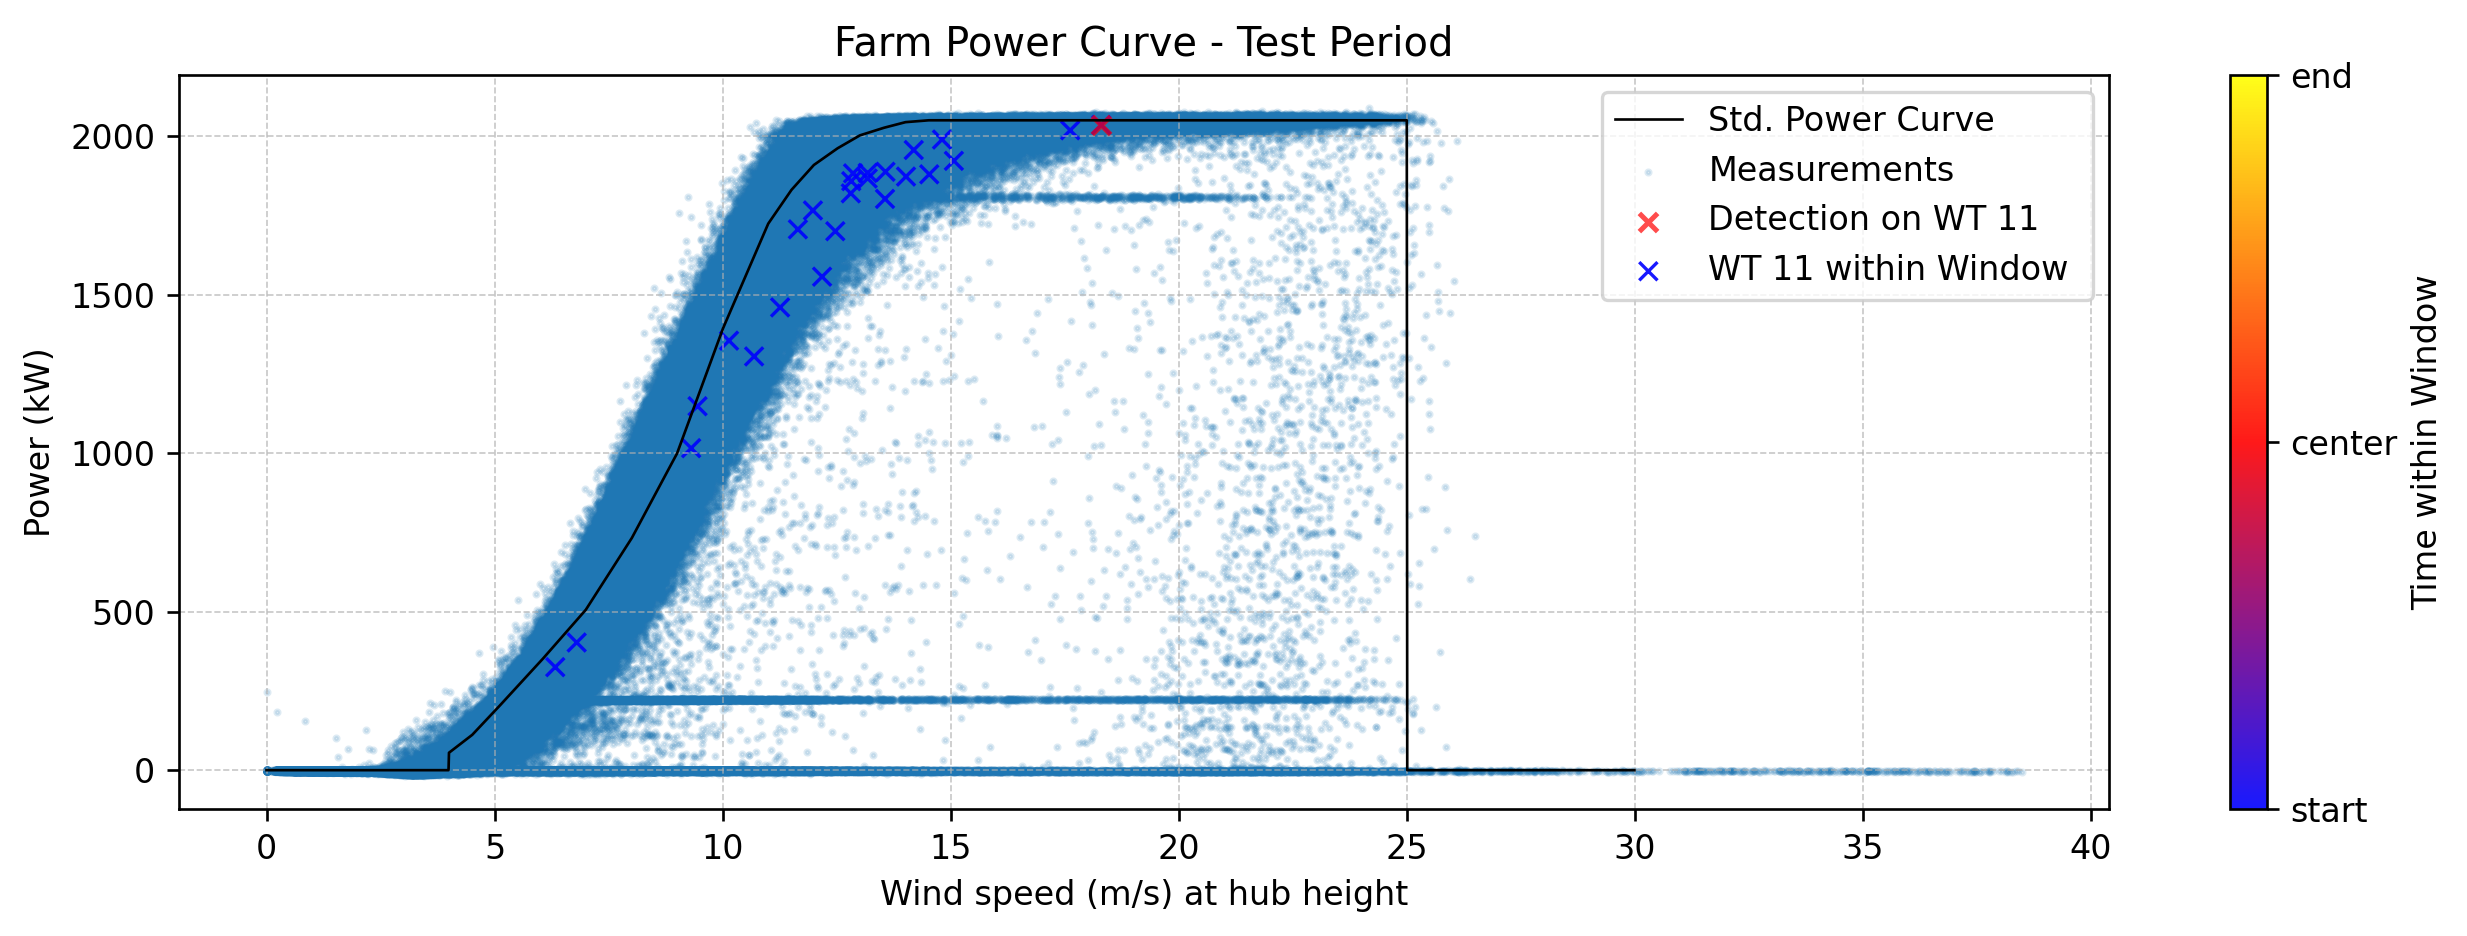

In [40]:
pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_df),
                    df_detections=df_det_points[(df_det_points[ic.WT_ID]== wt) & (df_det_points[ic.TS_COL]==detection_ts )],
                    detections_label=f"Detection on WT {wt}",
                    highlight_wt=wt,
                    highlight_ts_range=(pd.to_datetime(detection_ts )-pd.Timedelta(hours=2), pd.to_datetime(detection_ts )+pd.Timedelta(hours=2)),
                    alpha_det=0.7,
                    fig_size=(11,4),
                    save_dir=Path(ic.PATH_PRINTS),
                    file_name="p2_3_pc",
                    )

In [41]:
print(wt)

11


In [42]:
status_logs = pd.read_csv(ic.PATH_PENMANSHIEL / f"Status_Logs_Complete_ID_{wt}.csv")
status_logs["Timestamp start"] = pd.to_datetime(status_logs["Timestamp start"], errors="coerce")
status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")

In [43]:
display(status_logs.head())

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category
0,2016-07-19 09:44:20,2016-07-20 15:13:59,29:29:39,Stop,3575,Minimum grid frequency,NaN,External stop (grid) (4),Out of Electrical Specification,11,NaN,NaN
1,2016-07-19 09:44:22,2016-07-19 09:45:30,00:01:08,Warning,77,Reduced power transformer,NaN,Warnings (27),NaN,11,NaN,NaN
2,2016-07-19 09:44:22,2016-08-18 15:10:55,725:26:33,Informational,3835,Cable panel breaker open,NaN,Warnings (27),NaN,11,NaN,NaN
3,2016-07-19 09:44:22,2016-08-18 15:10:55,725:26:33,Informational,3830,Supply circuit breaker earthed,NaN,Warnings (27),Full Performance,11,NaN,NaN
4,2016-07-19 09:44:22,2016-07-19 09:45:39,00:01:17,Warning,3875,Overload transf. fan inlet air,NaN,Warnings (27),NaN,11,NaN,NaN


In [44]:
print(detection_ts)

2022-07-06 17:40:00


In [45]:
filter = status_logs[( detection_ts >= status_logs["Timestamp start"] ) & (detection_ts <= status_logs["Timestamp end"] )]

display(filter)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,WT_ID,Global contract category,Custom contract category


In [46]:
delta = pd.Timedelta(days=3)
det_start = detection_ts - delta
det_end = detection_ts + delta

In [47]:
filter = status_logs[(status_logs["Timestamp start"] <= det_end) & (status_logs["Timestamp end"] >= det_start)]
display(filter["Status"].unique())
print(detection_ts)
a = filter[filter["Status"] == "Stop"]
b =filter[filter["Status"] == "Warning"]
stopwarn = pd.concat([a,b], axis=0)
stopwarn = stopwarn.sort_values(by=["Timestamp start"], ascending=[True])
stopwarn = stopwarn.drop(["Comment", "Custom contract category","Global contract category"],axis=1)

display(stopwarn)
#display(filter[filter["Status"] == "Informational"])


<ArrowStringArray>
['Informational', 'Stop', 'Communication', 'Warning']
Length: 4, dtype: str

2022-07-06 17:40:00


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID
47997,2022-07-05 07:00:01,2022-07-05 15:11:04,08:11:03,Stop,8000,Park master stop,Remote stop (30),Requested Shutdown,11
48003,2022-07-05 14:44:52,2022-07-05 15:11:04,00:26:12,Warning,2125,Timeout brake closed,Warnings (27),NaN,11
48077,2022-07-07 14:06:48,2022-07-07 14:18:35,00:11:47,Stop,6200,Cable autounwind,Operating states (28),Technical Standby,11


In [48]:
ltx = stopwarn.to_latex(index=False, escape=True)
with open(ic.PATH_PRINTS/"p2_3_status_logs.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

In [49]:
raw_test = pd.read_csv(ic.PATH_PART2_RAW_TEST / "raw_test.csv", parse_dates=[ic.TS_COL])

In [50]:
date = detection_ts

In [51]:
len(thermal_signals)

18

In [52]:
gen_sigs = ["Generator bearing front temperature (°C)",
            "Generator bearing rear temperature (°C)",
            "Stator temperature 1 (°C)"]

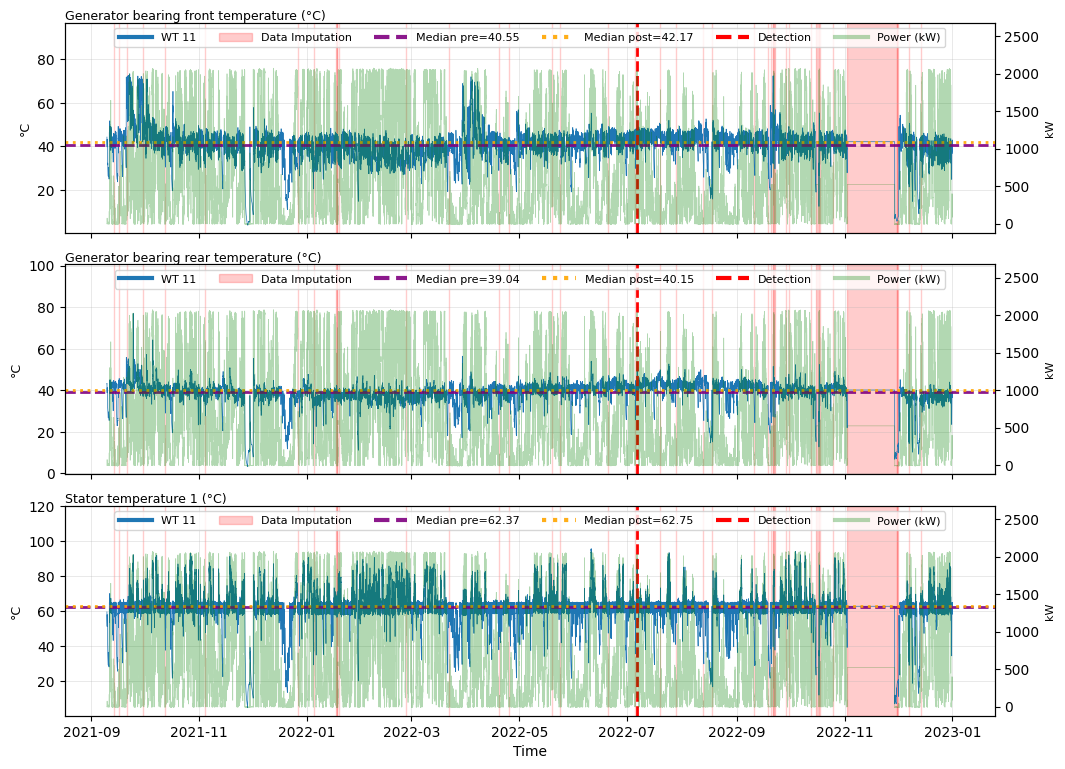

In [53]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=gen_sigs,
                        anomaly_spans= None,
                        fig_size=(12,3),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=300),detection_ts + pd.Timedelta(days=300)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=0.5,
                        save_path=Path(ic.PATH_PRINTS/ f"p2-33_signals_compact_rel_sigs_wt_{wt}")
                        )

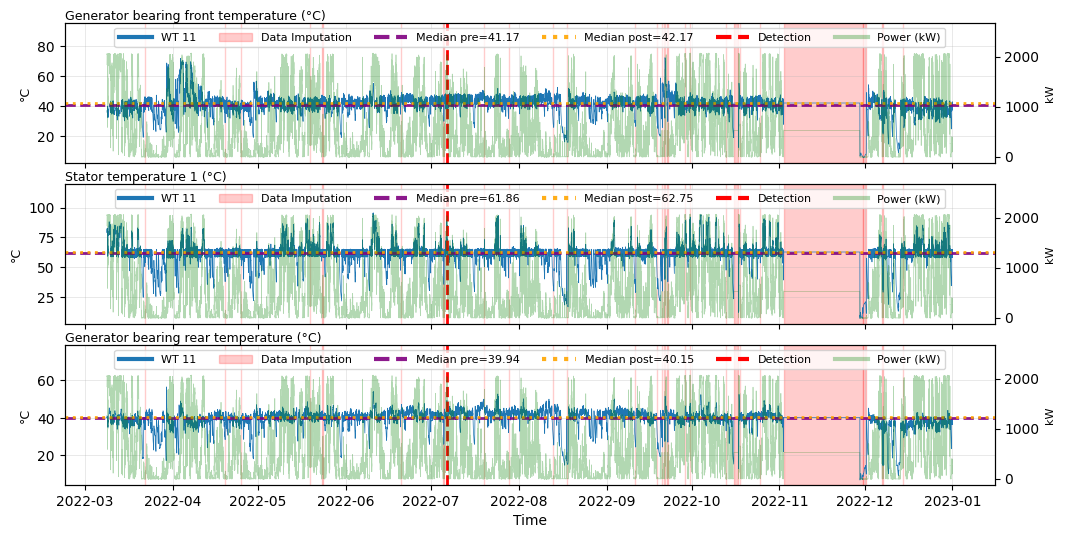

In [57]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=relevant_sigs,
                        anomaly_spans= None,
                        fig_size=(12,2),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=120),detection_ts + pd.Timedelta(days=300)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=0.5,
                        save_path=Path(ic.PATH_PRINTS/ f"p2-33_signals_compact_rel_sigs_wt_{wt}")
                        )

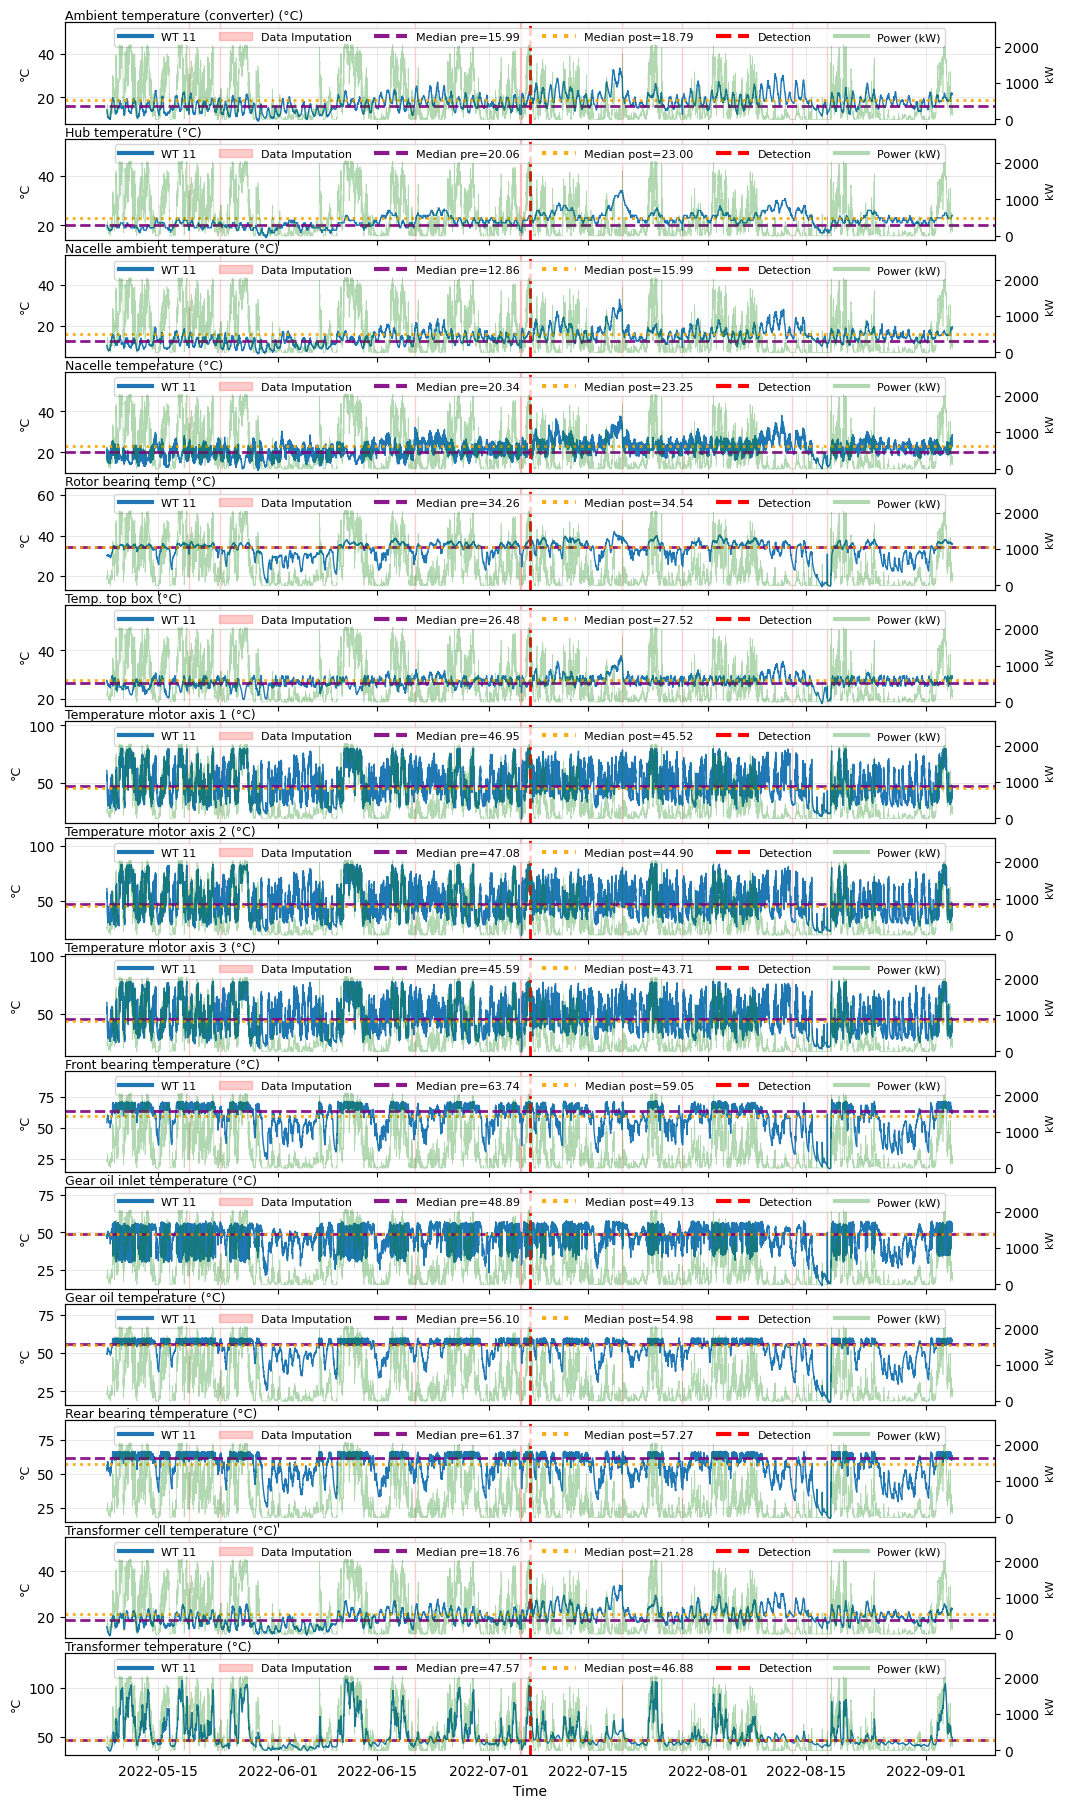

In [55]:
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=[sig for sig in thermal_signals if sig not in relevant_sigs],
                        anomaly_spans= None,
                        fig_size=(12,1.5),
                        ts_mark=[detection_ts],
                        ts_range=(detection_ts- pd.Timedelta(days=60),detection_ts + pd.Timedelta(days=60)),
                        mean_linewidth=2.0,
                        plot_power= True,
                        power_col = "Power (kW)",
                        power_alpha = 0.3,
                        power_linewidth = 0.5,
                        sig_linewidth=1,
                        save_path=Path(ic.PATH_PRINTS / f"p2-33-rest_signals_compact_wt_{wt}.png")
                        )

Drive train acceleration (mm/ss)
Gear oil inlet pressure (bar)
Gear oil pump pressure (bar)
Gearbox speed (RPM)
Generator RPM (RPM)
Motor current axis 1 (A)
Motor current axis 2 (A)
Motor current axis 3 (A)
Nacelle position (°)
Power (kW)
Rotor speed (RPM)
Vane position 1+2 (°)
Wind direction (°)
Wind speed (m/s)
Blade angle (pitch position) A (°)
Blade angle (pitch position) B (°)
Blade angle (pitch position) C (°)
Tower Acceleration X (mm/ss)
Tower Acceleration Y (mm/ss)
Yaw bearing angle (°)


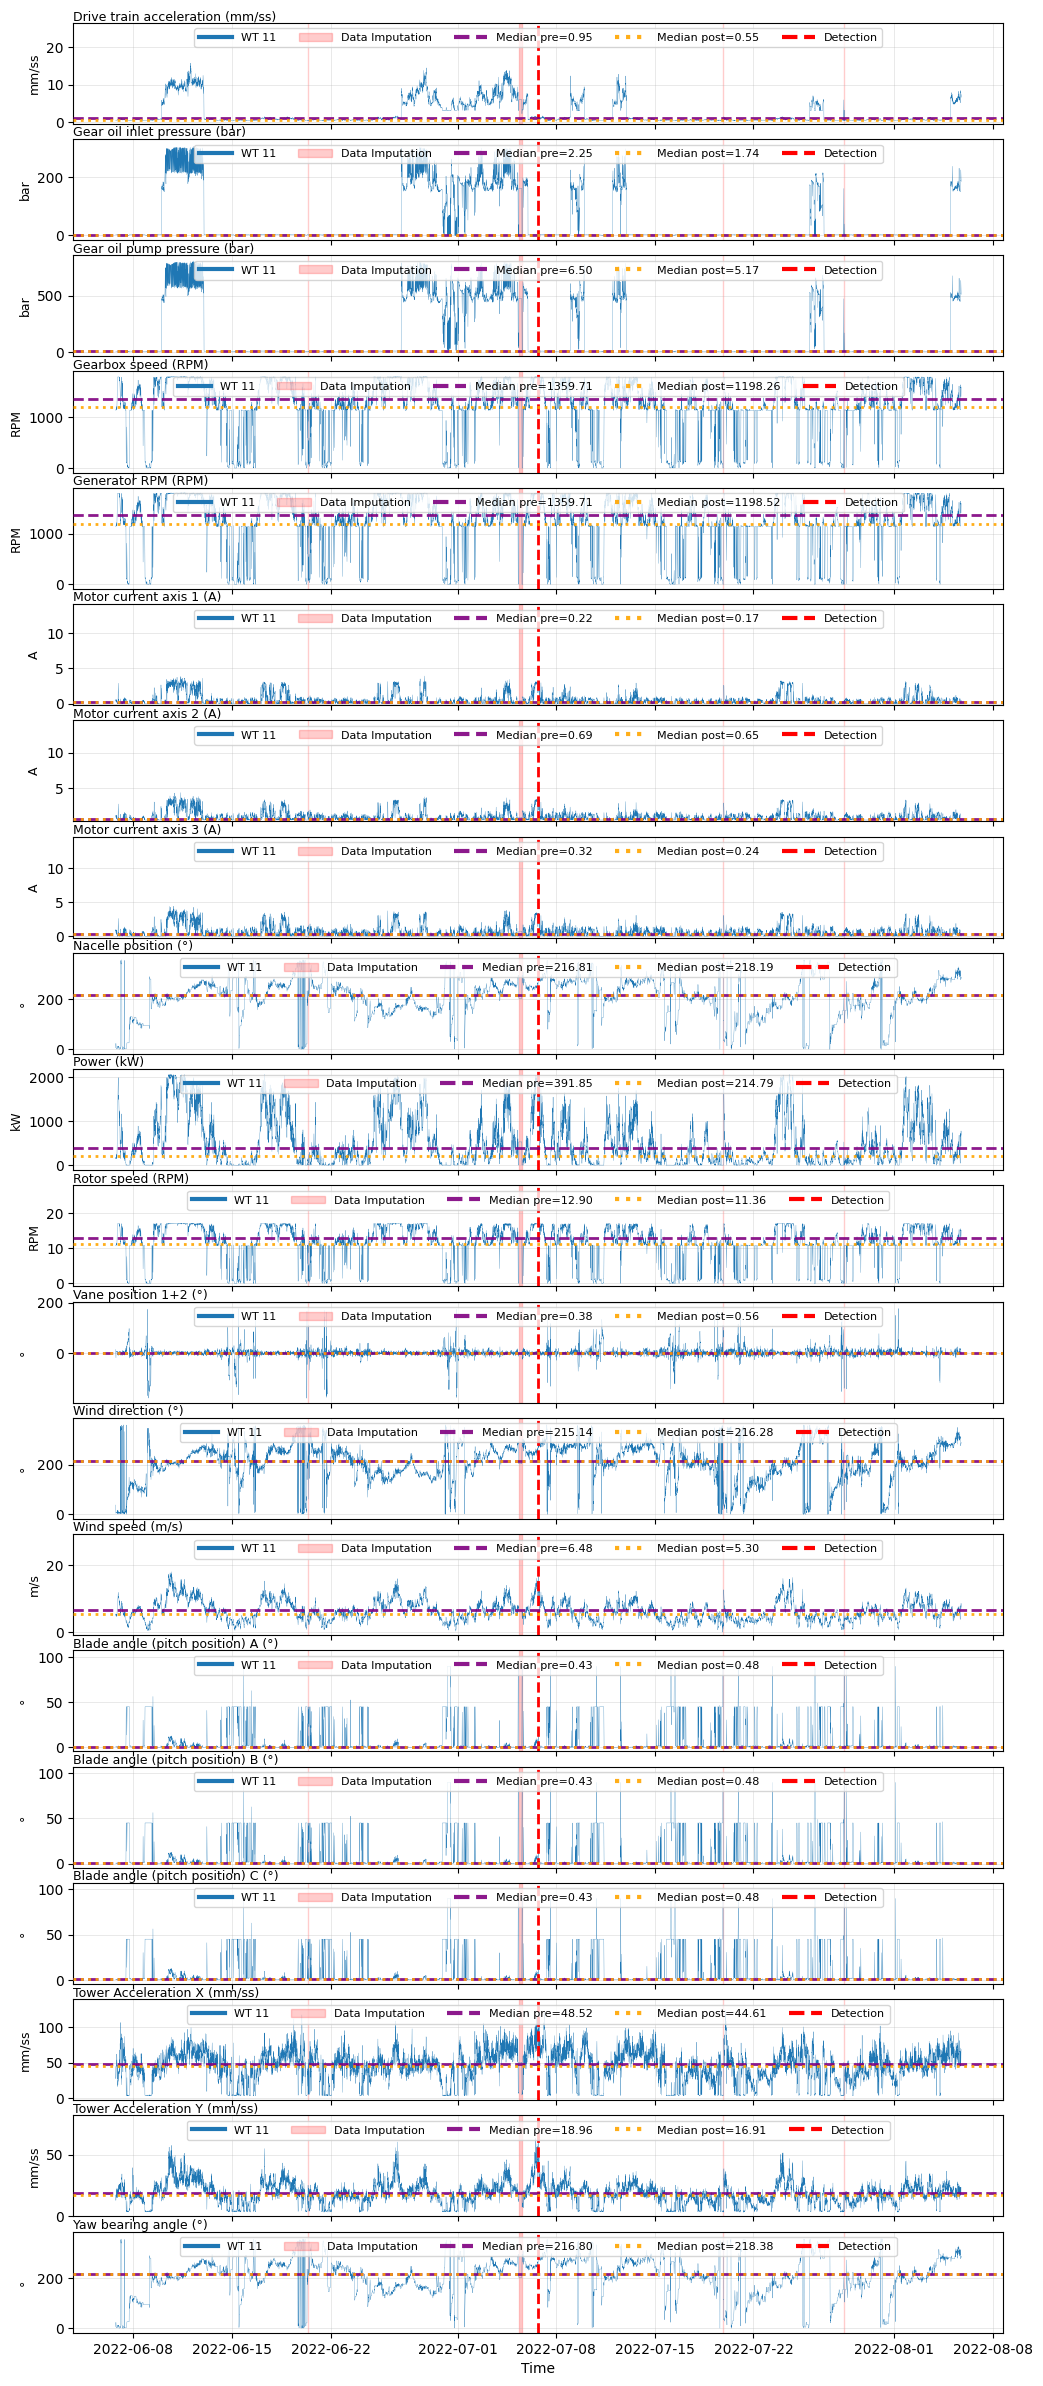

In [56]:
signals = [sig for sig in hfn.load_feature_order() if "(°C)" not in sig]
for sig in signals:
    print(sig)
    
pp.plot_signals_compact(df=wt_df,
                        wt_id = wt,
                        signals=signals,
                        anomaly_spans= None,
                        fig_size=(12,1.5),
                        ts_mark=date,
                        ts_range=(date - pd.Timedelta(days=30), date + pd.Timedelta(days=30)),
                        mean_linewidth=2.0
                        )